In [3]:
from pathlib import Path

# Get the current working directory
PROJECT_ROOT = Path.cwd()

# If the notebook is inside the notebooks directory, move to the project root
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Define data directories
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
CATALOG_DIR = DATA_DIR / "catalog"

# Define output directories
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_CATALOG_DIR = OUTPUT_DIR / "catalogs"

# Define source-code directory
SRC_DIR = PROJECT_ROOT / "src"

# Create directories if they do not exist
for folder in [
    RAW_DIR,
    CATALOG_DIR,
    FIGURE_DIR,
    OUTPUT_CATALOG_DIR,
    SRC_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

# Print directory paths
print("Project root :", PROJECT_ROOT)
print("Raw data     :", RAW_DIR)
print("Catalog      :", CATALOG_DIR)
print("Figures      :", FIGURE_DIR)

# Define input file paths
fits_path = RAW_DIR / "SKAMid_B2_1000h_v3.fits"
catalog_path = CATALOG_DIR / "TrainingSet_B2_v2.txt"

# Check whether the files exist
print("FITS exists   :", fits_path.exists())
print("Catalog exists:", catalog_path.exists())

# Display FITS file size
if fits_path.exists():
    print(f"FITS size: {fits_path.stat().st_size / 1024**3:.2f} GB")

# Display catalogue file size
if catalog_path.exists():
    print(f"Catalog size: {catalog_path.stat().st_size / 1024**2:.2f} MB")

Project root : D:\AST\radio_ska
Raw data     : D:\AST\radio_ska\data\raw
Catalog      : D:\AST\radio_ska\data\catalog
Figures      : D:\AST\radio_ska\outputs\figures
FITS exists   : True
Catalog exists: True
FITS size: 4.00 GB
Catalog size: 13.90 MB


Image shape: (32768, 32768)
Data type: >f4


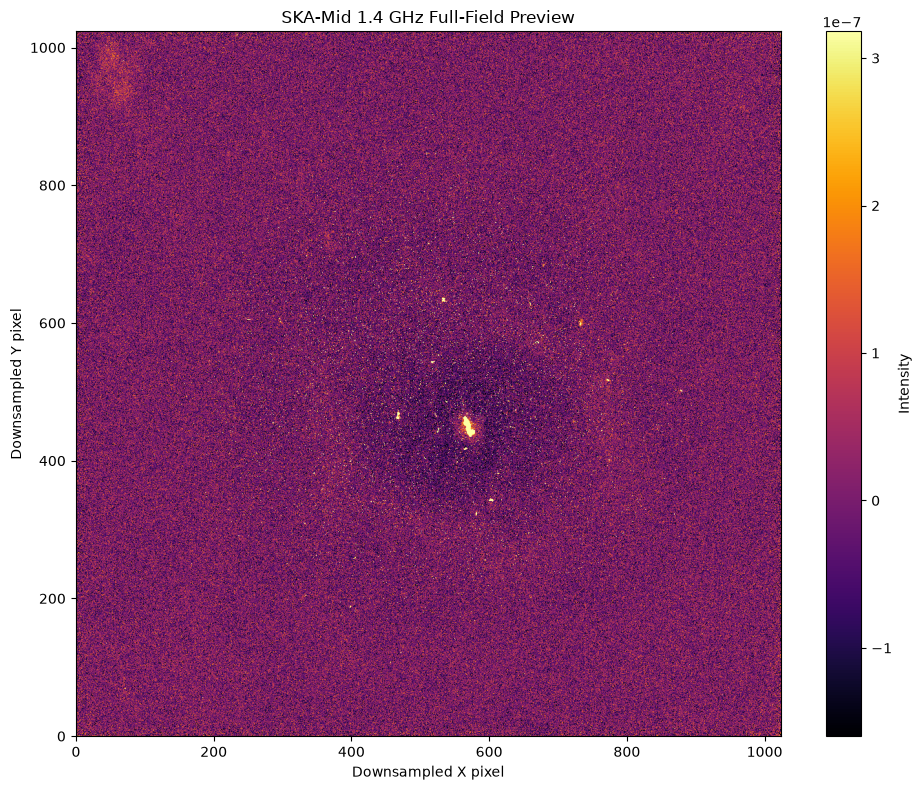

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Open the FITS image using memory mapping
with fits.open(fits_path, memmap=True) as hdul:
    image = np.squeeze(hdul[0].data)

    print("Image shape:", image.shape)
    print("Data type:", image.dtype)

    # Downsample the full image for visualization
    step = 32
    preview = image[::step, ::step].copy()

# Keep only finite values
finite = preview[np.isfinite(preview)]

# Use robust percentile limits to avoid bright sources dominating the display
vmin = np.percentile(finite, 1)
vmax = np.percentile(finite, 99.7)

plt.figure(figsize=(10, 8))

plt.imshow(
    preview,
    origin="lower",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="Intensity")
plt.xlabel("Downsampled X pixel")
plt.ylabel("Downsampled Y pixel")
plt.title("SKA-Mid 1.4 GHz Full-Field Preview")

plt.tight_layout()
plt.show()

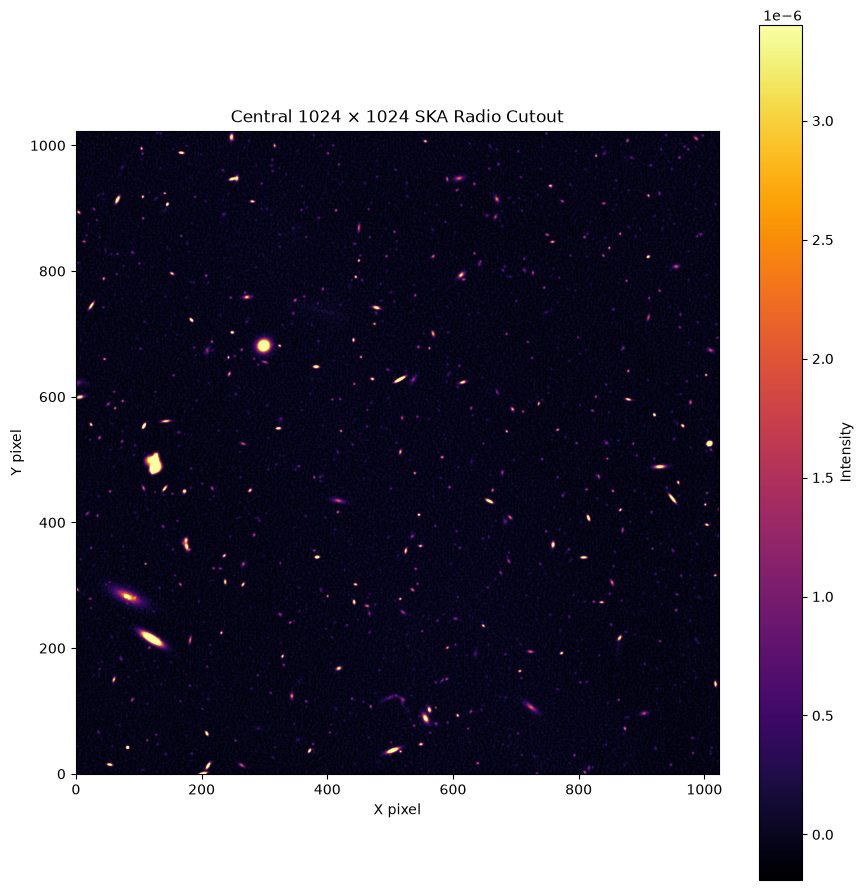

In [5]:


# Define the cutout size
cutout_size = 1024

with fits.open(fits_path, memmap=True) as hdul:
    image = np.squeeze(hdul[0].data)

    height, width = image.shape

    # Use the image center as the first inspection region
    center_x = width // 2
    center_y = height // 2

    half = cutout_size // 2

    x1 = center_x - half
    x2 = center_x + half
    y1 = center_y - half
    y2 = center_y + half

    # Copy only the selected region into memory
    cutout = image[y1:y2, x1:x2].copy()

finite = cutout[np.isfinite(cutout)]

vmin = np.percentile(finite, 1)
vmax = np.percentile(finite, 99.8)

plt.figure(figsize=(9, 9))

plt.imshow(
    cutout,
    origin="lower",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="Intensity")
plt.xlabel("X pixel")
plt.ylabel("Y pixel")
plt.title("Central 1024 × 1024 SKA Radio Cutout")

plt.tight_layout()
plt.show()

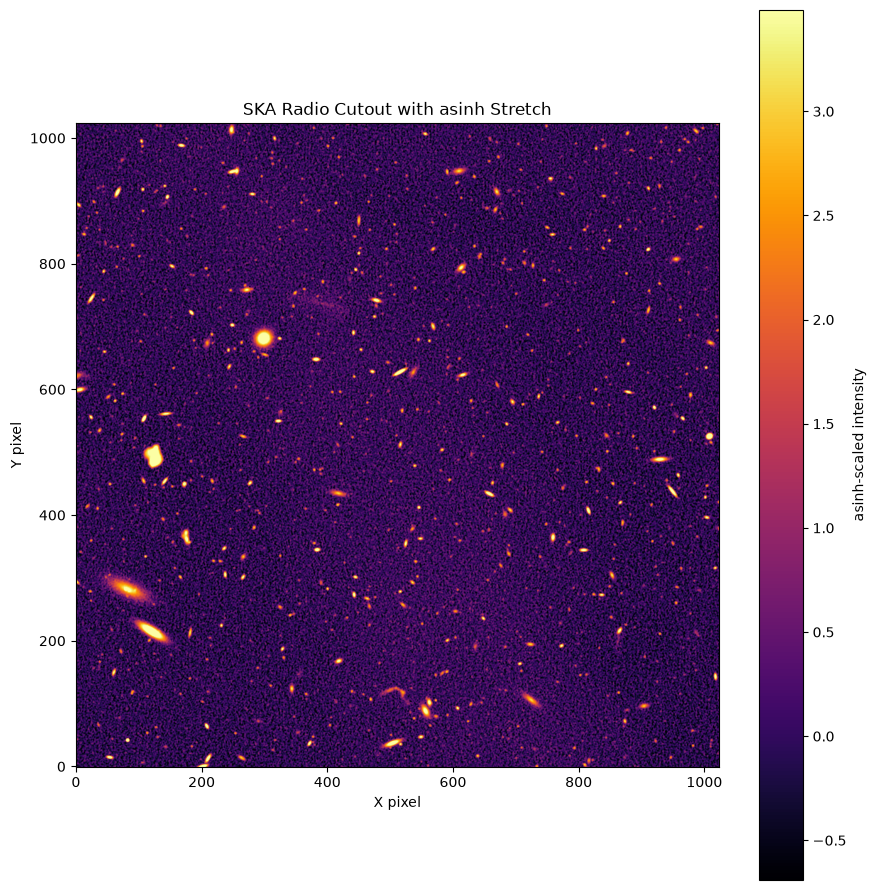

In [6]:
# asinh

# Estimate a robust central value
median = np.nanmedian(cutout)

# Estimate a robust noise scale using MAD
mad = np.nanmedian(np.abs(cutout - median))
sigma = 1.4826 * mad

# Apply an asinh stretch
stretched = np.arcsinh((cutout - median) / (3 * sigma))

finite = stretched[np.isfinite(stretched)]

vmin = np.percentile(finite, 1)
vmax = np.percentile(finite, 99.8)

plt.figure(figsize=(9, 9))

plt.imshow(
    stretched,
    origin="lower",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="asinh-scaled intensity")
plt.xlabel("X pixel")
plt.ylabel("Y pixel")
plt.title("SKA Radio Cutout with asinh Stretch")

plt.tight_layout()
plt.show()

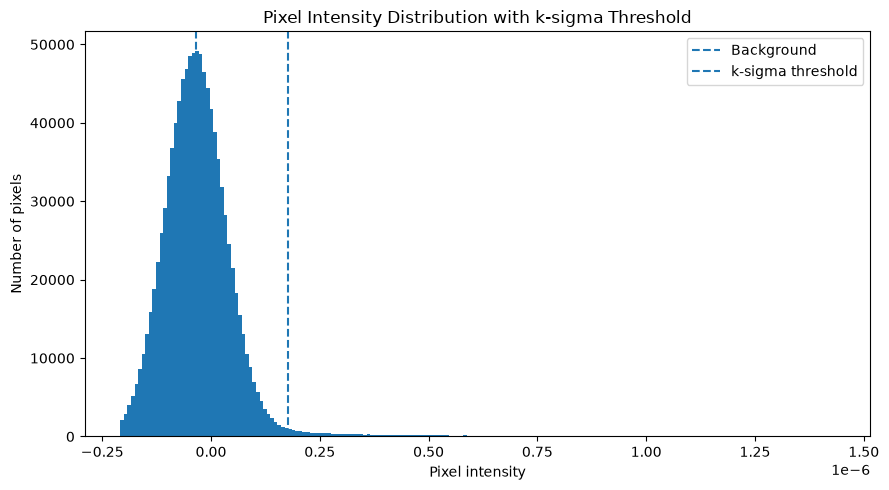

Background: -3.420829e-08
Sigma: 7.020958e-08
k-sigma threshold: 1.7642046e-07


In [15]:
pixels = cutout[np.isfinite(cutout)] 
k = 3
# Estimate the background level using the median
background = np.median(pixels)

# Estimate the noise level using MAD
mad = np.median(np.abs(pixels - background))
sigma = 1.4826 * mad

# Define the k-sigma detection threshold
threshold_ksigma = background + k * sigma

# Restrict the histogram to the central intensity range
low = np.percentile(pixels, 0.5)
high = np.percentile(pixels, 99.5)

selected = pixels[
    (pixels >= low) &
    (pixels <= high)
]

plt.figure(figsize=(9, 5))

plt.hist(
    selected,
    bins=200
)

# Draw the background level
plt.axvline(
    background,
    linestyle="--",
    label="Background"
)

# Draw the k-sigma detection threshold
plt.axvline(
    threshold_ksigma,
    linestyle="--",
    label="k-sigma threshold"
)

plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.title("Pixel Intensity Distribution with k-sigma Threshold")

plt.legend()
plt.tight_layout()
plt.show()

print("Background:", background)
print("Sigma:", sigma)
print("k-sigma threshold:", threshold_ksigma)

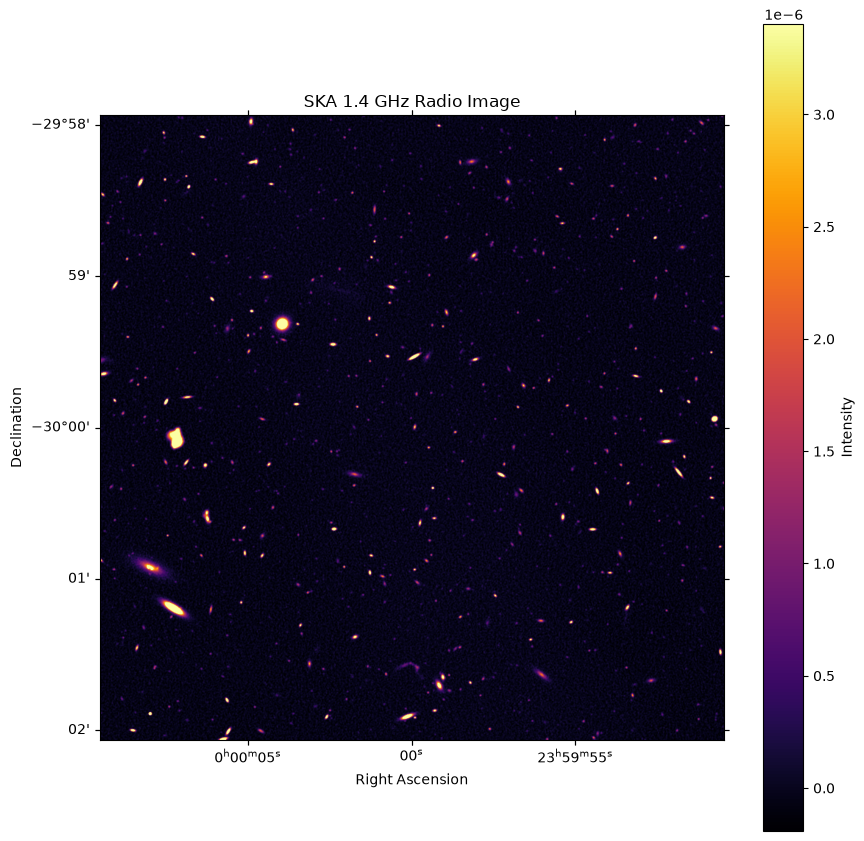

In [8]:
from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata import Cutout2D

with fits.open(fits_path, memmap=True) as hdul:
    image = np.squeeze(hdul[0].data)
    header = hdul[0].header

# Create the WCS object
wcs = WCS(header).celestial

# Define the cutout center
position = (
    image.shape[1] // 2,
    image.shape[0] // 2
)

# Create a WCS-aware cutout
wcs_cutout = Cutout2D(
    image,
    position=position,
    size=(1024, 1024),
    wcs=wcs
)

data = wcs_cutout.data

finite = data[np.isfinite(data)]
vmin = np.percentile(finite, 1)
vmax = np.percentile(finite, 99.8)

fig = plt.figure(figsize=(9, 9))

ax = fig.add_subplot(
    111,
    projection=wcs_cutout.wcs
)

im = ax.imshow(
    data,
    origin="lower",
    cmap="inferno",
    vmin=vmin,
    vmax=vmax
)

ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")
ax.set_title("SKA 1.4 GHz Radio Image")

plt.colorbar(
    im,
    ax=ax,
    label="Intensity"
)

plt.tight_layout()
plt.show()